In [2]:
import pandas as pd
# Load the dataframes with index and columns
df1 = pd.read_csv('co_occurrence_JD_skills_cluster.csv', index_col=0)
df2 = pd.read_csv('co_occurrence_skills_embedd_cluster.csv', index_col=0)
df3 = pd.read_csv('co_occurrence_JD_feature_skills_cluster.csv', index_col=0)
# Ensure the dataframes are aligned by reindexing df2 to match df1
# df2 = df2.reindex(index=df1.index, columns=df1.columns)

# Check that the indices and columns match
assert (df1.index == df2.index).all(), "The rows (skills) are not in the same order"
assert (df1.index == df3.index).all(), "The rows (skills) are not in the same order"
assert (df1.columns == df2.columns).all(), "The columns (skills) are not in the same order"

In [3]:
combined_matrix = df1.values + df2.values + df3.values

In [4]:
# Create a DataFrame from the combined matrix
combined_matrix_df = pd.DataFrame(combined_matrix, index=df1.index, columns=df1.columns)
combined_matrix_df

,Python,R,SQL,Java,Scala,C,C++,Javascript,Matlab,"Julia, Ruby",...,API design and development,Interpersonal skills,Time management,Continuous learning,Selfmotivation,Problemsolving,Critical thinking,Stakeholder management,Customer service,Writing skills
Python,0.0,3.0,3.0,3.0,3.0,3.0,1.0,3.0,3.0,1.0,...,0.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
R,3.0,0.0,3.0,3.0,3.0,3.0,1.0,3.0,3.0,1.0,...,0.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
SQL,3.0,3.0,0.0,3.0,3.0,3.0,1.0,3.0,2.0,1.0,...,0.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0
Java,3.0,3.0,3.0,0.0,3.0,3.0,1.0,3.0,2.0,1.0,...,0.0,2.0,2.0,2.0,0.0,2.0,2.0,0.0,2.0,2.0
Scala,3.0,3.0,3.0,3.0,0.0,3.0,1.0,3.0,2.0,1.0,...,0.0,2.0,2.0,2.0,0.0,2.0,2.0,1.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Problemsolving,2.0,2.0,2.0,2.0,2.0,2.0,0.0,2.0,1.0,0.0,...,0.0,2.0,2.0,3.0,0.0,0.0,3.0,1.0,2.0,1.0
Critical thinking,2.0,2.0,2.0,2.0,2.0,2.0,0.0,2.0,0.0,0.0,...,0.0,1.0,1.0,2.0,0.0,3.0,0.0,0.0,2.0,0.0
Stakeholder management,2.0,2.0,2.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
Customer service,2.0,2.0,2.0,2.0,2.0,2.0,0.0,2.0,0.0,0.0,...,0.0,3.0,0.0,2.0,1.0,2.0,2.0,0.0,0.0,1.0


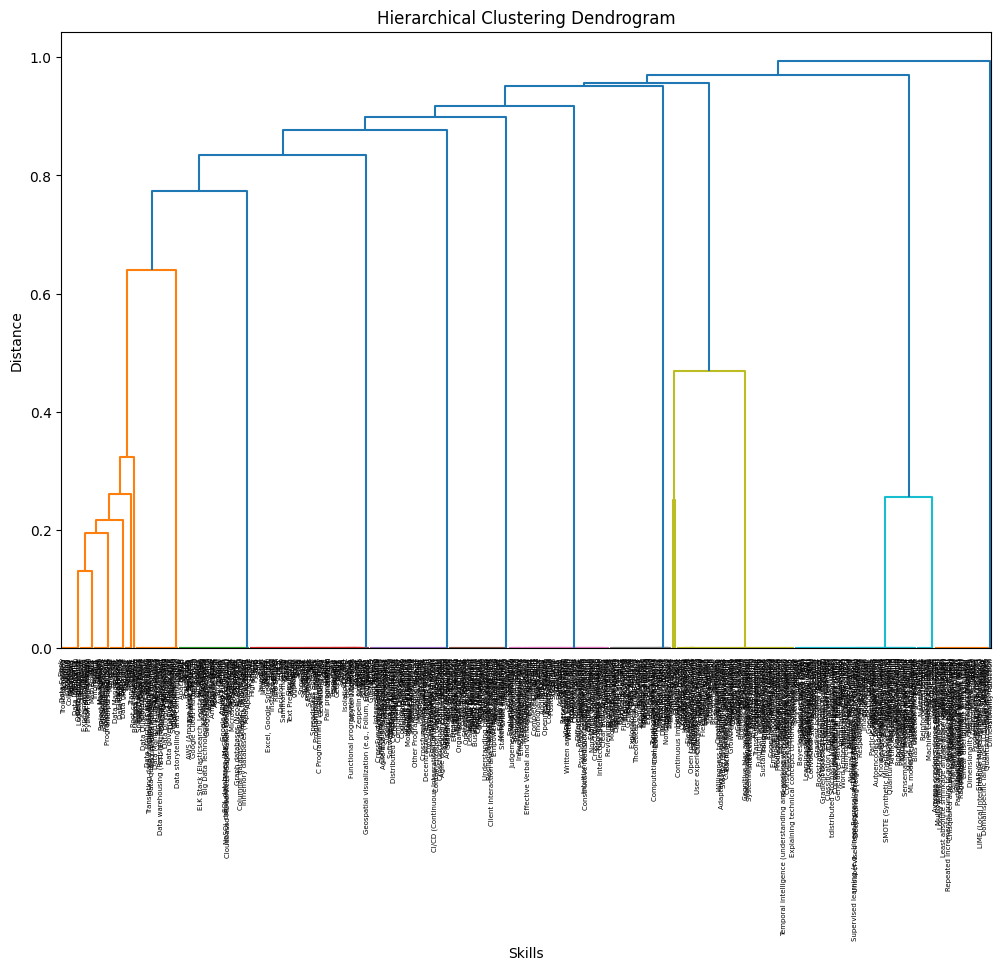

Cluster 1:
  - Average onedependence estimators (AODE)
  - Linear regression
  - Ordinary Least Squares Regression (OLSR)
  - Stepwise regression
  - Multivariate adaptive regression splines (MARS)
  - Locally estimated scatterplot smoothing (LOESS)
  - Regularisation
  - Ridge regression
  - Least absolute shrinkage and selection operator (LASSO)
  - Lest angle regression (LARS)
  - One rule (OneR)
  - Zero rule (ZeroR)
  - Repeated incremental pruning to produce error reduction (RIPPER)
  - Iterative dichotomiser 3 (ID3)
  - Chisquared automatic interaction detection (CHAID)
  - Dimensionality Reduction
  - Principal component analysis (PCA)
  - Partial least squares regression (PLSR)
  - Multidimensional scaling (MDS)
  - Projection pursuit
  - Principal component regression (PCR)
  - Partial least squares discriminant analysis
  - Mixture discriminant analysis (MDA)
  - Quadratic discriminant analysis (QDA)
  - REgularized discriminant analysis (RDA)
  - Flexible discriminant analy

In [5]:
import pandas as pd
import numpy as np
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

# Assuming that the co-occurrence matrix is a similarity matrix
distances = 1 - combined_matrix_df.values  # Convert similarity to distance
np.fill_diagonal(distances, 0)  # Ensure diagonal elements are zero

# Ensure the distance matrix is symmetric
distances = (distances + distances.T) / 2

# Ensure distances are non-negative (just a precaution)
distances[distances < 0] = 0

# Perform hierarchical clustering
linkage_matrix = hierarchy.linkage(squareform(distances), method='average')

# Plot dendrogram
plt.figure(figsize=(12, 8))
dendrogram = hierarchy.dendrogram(linkage_matrix, labels=combined_matrix_df.index.tolist(), orientation='top', distance_sort='descending')
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Skills')
plt.ylabel('Distance')
plt.show()

# Cut the dendrogram at a specific threshold to form flat clusters
# Adjust 't' to get the desired number of clusters
threshold = 0.7  # This is an example threshold; adjust it based on your data
clusters = hierarchy.fcluster(linkage_matrix, t=threshold, criterion='distance')

# Create a DataFrame to map skills to their cluster labels
clustered_skills = pd.DataFrame({'Skill': combined_matrix_df.index, 'Cluster': clusters})

# Group skills by their cluster labels and print the results
for cluster_label, group in clustered_skills.groupby('Cluster'):
    print(f'Cluster {cluster_label}:')
    for skill in group['Skill']:
        print(f'  - {skill}')
    print()  # Add a blank line between clusters


# Reshape the DataFrame to have clusters as columns and skills in those clusters
ensembled_clusters = clustered_skills

# Save the reshaped DataFrame to a CSV file
clusters_file_path = 'clust_ensembled.csv'
ensembled_clusters.to_csv(clusters_file_path, index=False)

print(f"Clusters saved to '{clusters_file_path}'")
